In [109]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from tensorboardX import SummaryWriter
from sklearn.metrics import mean_squared_error




# Load Data

In [110]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
train_ids = train["Id"]
test_ids = test["Id"]
X_train = train.drop(["Id", "SalePrice"], axis=1)
y_train = train["SalePrice"]
X_test = test.drop(["Id"], axis=1)

# Log-transform target
y_log = np.log1p(y_train)

# EDA

In [111]:
# fill nan values with 0
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(0)

In [112]:
# Identify numerical features
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

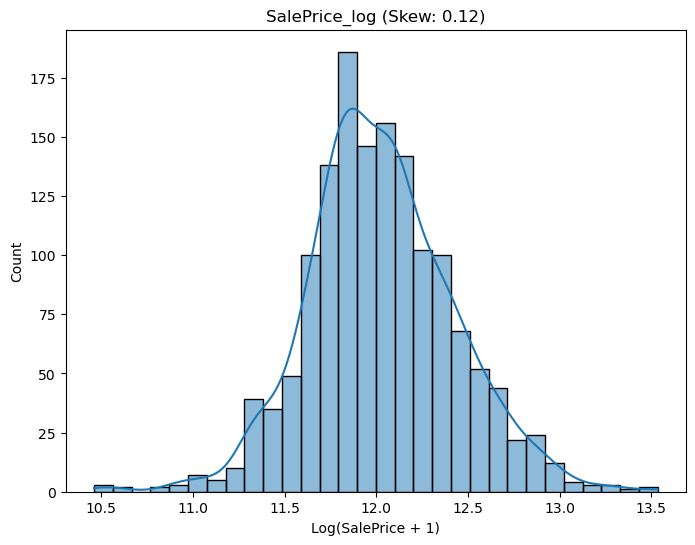


Outliers Detected (IQR Method):
MSSubClass: 103 outliers (Lower: -55.00, Upper: 145.00)
LotFrontage: 16 outliers (Lower: -13.50, Upper: 134.50)
LotArea: 69 outliers (Lower: 1481.50, Upper: 17673.50)
MasVnrArea: 96 outliers (Lower: -249.00, Upper: 415.00)
BsmtFinSF1: 7 outliers (Lower: -1068.38, Upper: 1780.62)
BsmtFinSF2: 167 outliers (Lower: 0.00, Upper: 0.00)
BsmtUnfSF: 29 outliers (Lower: -654.50, Upper: 1685.50)
TotalBsmtSF: 61 outliers (Lower: 42.00, Upper: 2052.00)
1stFlrSF: 20 outliers (Lower: 118.12, Upper: 2155.12)
2ndFlrSF: 2 outliers (Lower: -1092.00, Upper: 1820.00)
LowQualFinSF: 26 outliers (Lower: 0.00, Upper: 0.00)
GrLivArea: 31 outliers (Lower: 158.62, Upper: 2747.62)
GarageArea: 21 outliers (Lower: -27.75, Upper: 938.25)
WoodDeckSF: 32 outliers (Lower: -252.00, Upper: 420.00)
OpenPorchSF: 77 outliers (Lower: -102.00, Upper: 170.00)
EnclosedPorch: 208 outliers (Lower: 0.00, Upper: 0.00)
3SsnPorch: 24 outliers (Lower: 0.00, Upper: 0.00)
ScreenPorch: 116 outliers (Lower:

In [113]:
# Filter out Year and count columns
exclude_cols = [
    "YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold",  # Year columns
    "OverallQual", "OverallCond", "BsmtFullBath", "BsmtHalfBath",  # Count/ordinal
    "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr",
    "TotRmsAbvGrd", "Fireplaces", "GarageCars", "MoSold"
]
filtered_num_features = [col for col in num_features if col not in exclude_cols]

# Plot histogram for SalePrice_log
plt.figure(figsize=(8, 6))
sns.histplot(y_log, bins=30, kde=True)
plt.title(f"SalePrice_log (Skew: {y_log.skew():.2f})")
plt.xlabel("Log(SalePrice + 1)")
plt.show()

# Outlier detection using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return len(outliers), lower_bound, upper_bound

print("\nOutliers Detected (IQR Method):")
for col in filtered_num_features + ["SalePrice_log"]:
    if col == "SalePrice_log":
        n_outliers, lower, upper = detect_outliers(pd.DataFrame({"SalePrice_log": y_log}), "SalePrice_log")
    else:
        n_outliers, lower, upper = detect_outliers(X_train, col)
    print(f"{col}: {n_outliers} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

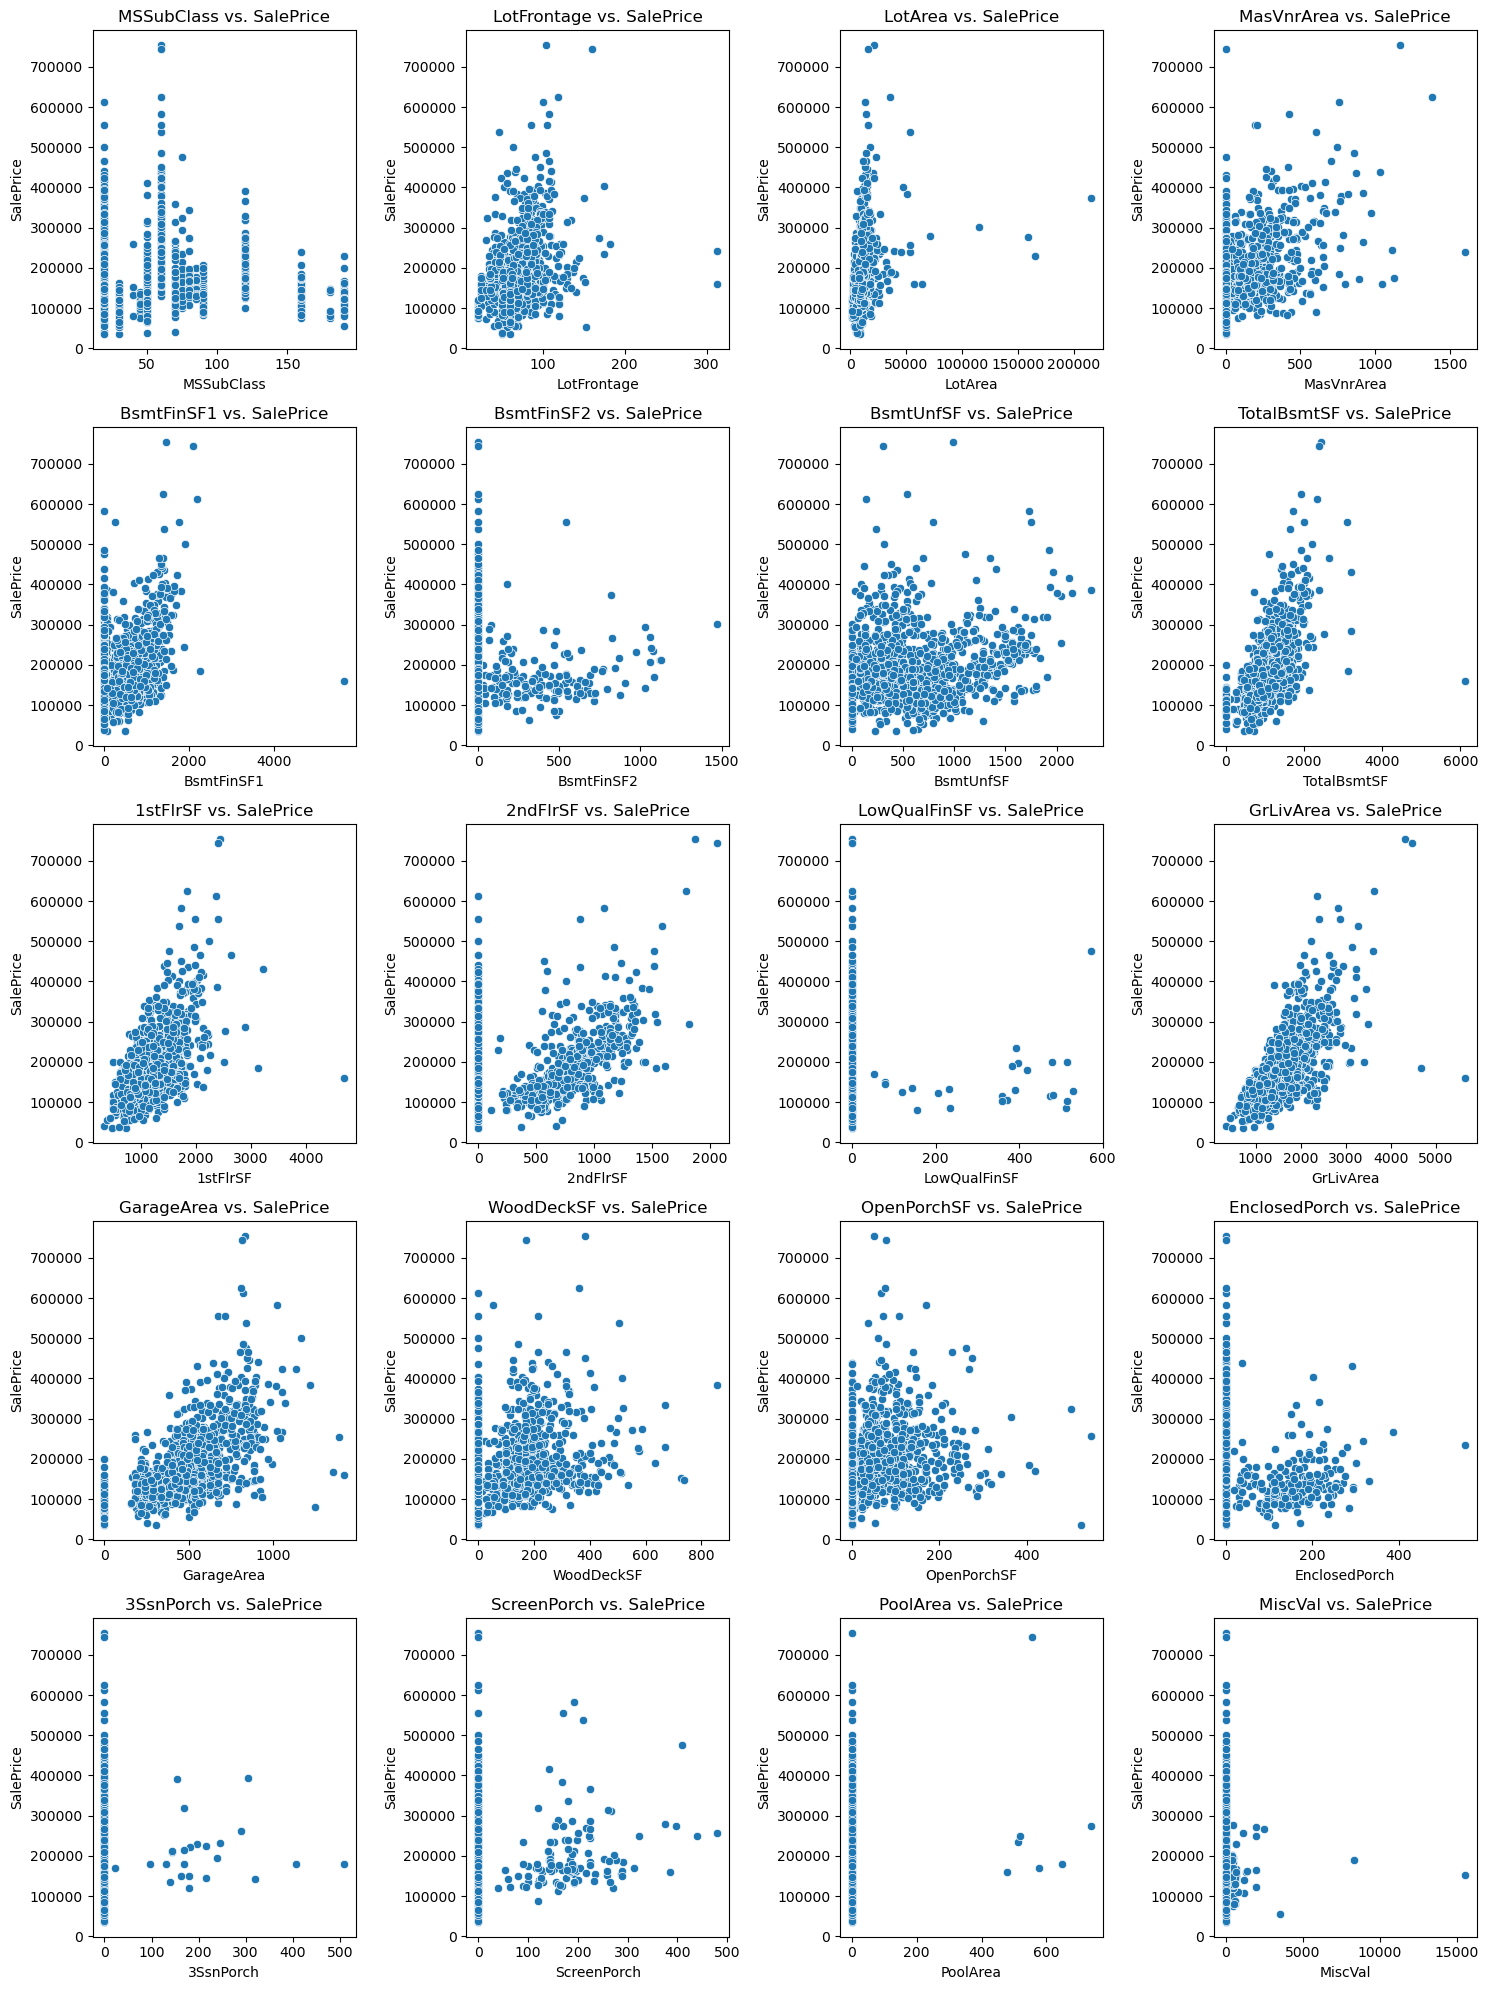

In [114]:
# Features with outliers (from your IQR results)
features = [
    "MSSubClass", "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1",
    "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
    "LowQualFinSF", "GrLivArea", "GarageArea", "WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal"
]

# Plot scatter plots
plt.figure(figsize=(15, 20))
for i, col in enumerate(features, 1):
    plt.subplot(5, 4, i)  # 5x4 grid for 20 features
    sns.scatterplot(x=train[col], y=train["SalePrice"])
    plt.title(f"{col} vs. SalePrice")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()


In [115]:
cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()
for col in cat_features:
    X_train[col] = X_train[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")

kf = KFold(n_splits=5, shuffle=True, random_state=42)


log_dir = "logs/catboost_cv_v5"


# Initialize TensorBoard writer
writer = SummaryWriter(log_dir=log_dir)

# Perform CV
fold = 0
rmses = []

for train_idx, val_idx in kf.split(X_train):
    fold += 1
    X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_t_log, y_v_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
    
    train_pool = Pool(X_t, y_t_log, cat_features=cat_features)
    val_pool = Pool(X_v, y_v_log, cat_features=cat_features)
    
    model = CatBoostRegressor(
        early_stopping_rounds=20,
        depth=4,
        learning_rate=0.05,
        l2_leaf_reg=6,
        loss_function="RMSE",
        verbose=1
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    
    # Log metrics for this fold
    for i, (train_rmse, val_rmse) in enumerate(zip(model.evals_result_["learn"]["RMSE"], model.evals_result_["validation"]["RMSE"])):
        writer.add_scalar(f"Fold_{fold}/Train_RMSE", train_rmse, i)
        writer.add_scalar(f"Fold_{fold}/Val_RMSE", val_rmse, i)
        
        # Compute validation RMSE
    y_pred_log = model.predict(X_v)
    rmse = np.sqrt(mean_squared_error(y_v_log, y_pred_log))
    rmses.append(rmse)
    print(f"Fold {fold} RMSE: {rmse:.4f}")

writer.close()
print(f"Average CV RMSE: {np.mean(rmses):.4f}")

writer.close()

0:	learn: 0.3788275	test: 0.4211330	best: 0.4211330 (0)	total: 13.2ms	remaining: 13.2s
1:	learn: 0.3675660	test: 0.4092485	best: 0.4092485 (1)	total: 18.2ms	remaining: 9.11s
2:	learn: 0.3564772	test: 0.3973883	best: 0.3973883 (2)	total: 22.1ms	remaining: 7.35s
3:	learn: 0.3462528	test: 0.3865496	best: 0.3865496 (3)	total: 25.2ms	remaining: 6.28s
4:	learn: 0.3369863	test: 0.3765669	best: 0.3765669 (4)	total: 29.3ms	remaining: 5.83s
5:	learn: 0.3280952	test: 0.3672914	best: 0.3672914 (5)	total: 32.9ms	remaining: 5.46s
6:	learn: 0.3198553	test: 0.3580540	best: 0.3580540 (6)	total: 36.1ms	remaining: 5.12s
7:	learn: 0.3122274	test: 0.3498896	best: 0.3498896 (7)	total: 39ms	remaining: 4.84s
8:	learn: 0.3046953	test: 0.3417445	best: 0.3417445 (8)	total: 42.6ms	remaining: 4.69s
9:	learn: 0.2964942	test: 0.3331475	best: 0.3331475 (9)	total: 47.1ms	remaining: 4.66s
10:	learn: 0.2894312	test: 0.3256546	best: 0.3256546 (10)	total: 49.9ms	remaining: 4.48s
11:	learn: 0.2833368	test: 0.3192494	best: 

Feature Importance:
         Feature  Importance
16   OverallQual   27.120065
45     GrLivArea   14.079424
37   TotalBsmtSF    5.999060
42      1stFlrSF    4.119308
26     ExterQual    3.954062
..           ...         ...
28    Foundation    0.000386
68     3SsnPorch    0.000000
4         Street    0.000000
8      Utilities    0.000000
47  BsmtHalfBath    0.000000

[79 rows x 2 columns]


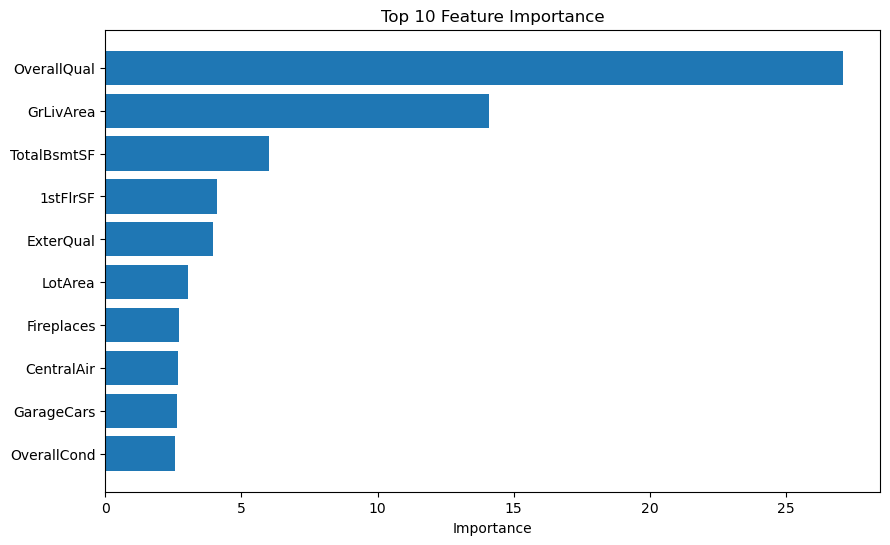

In [116]:
# Get feature importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

# Display top features
print("Feature Importance:")
print(importance)

# Optional: Plot feature importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"][:10], importance["Importance"][:10])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

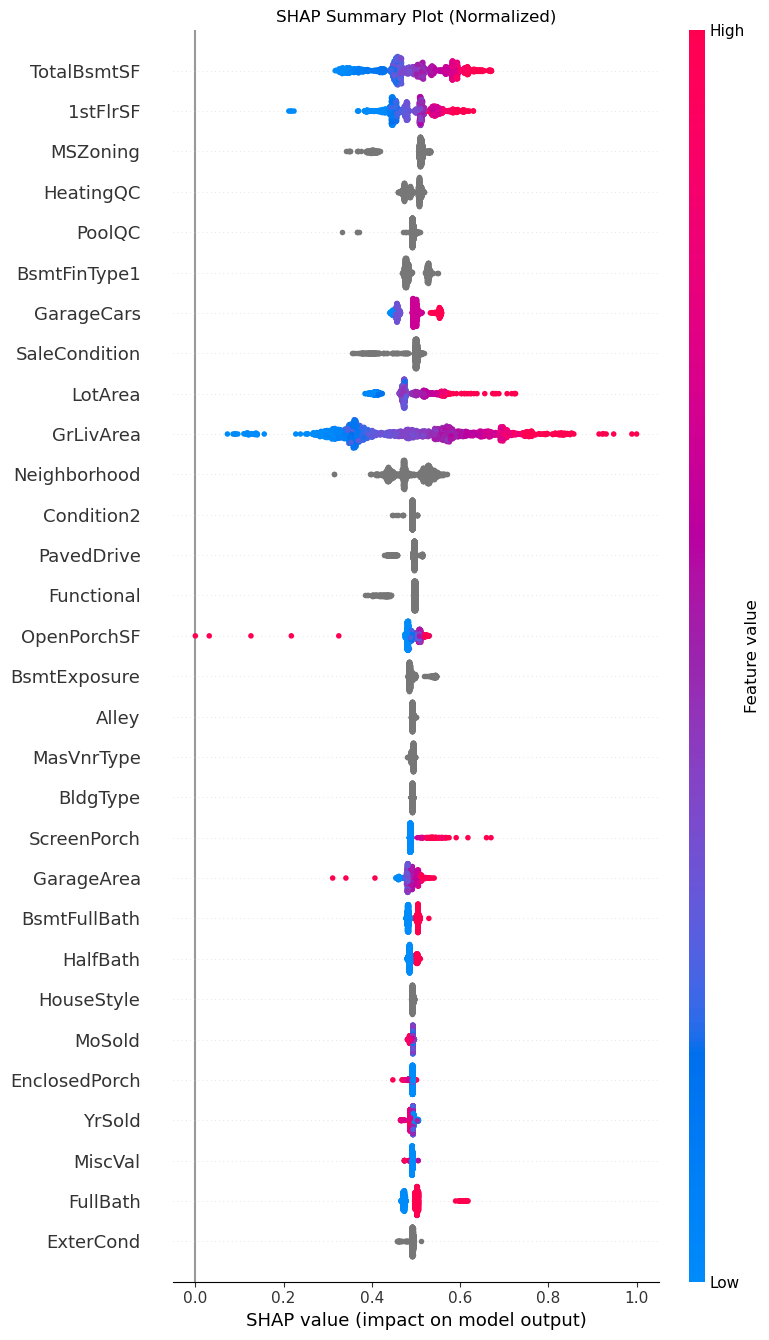

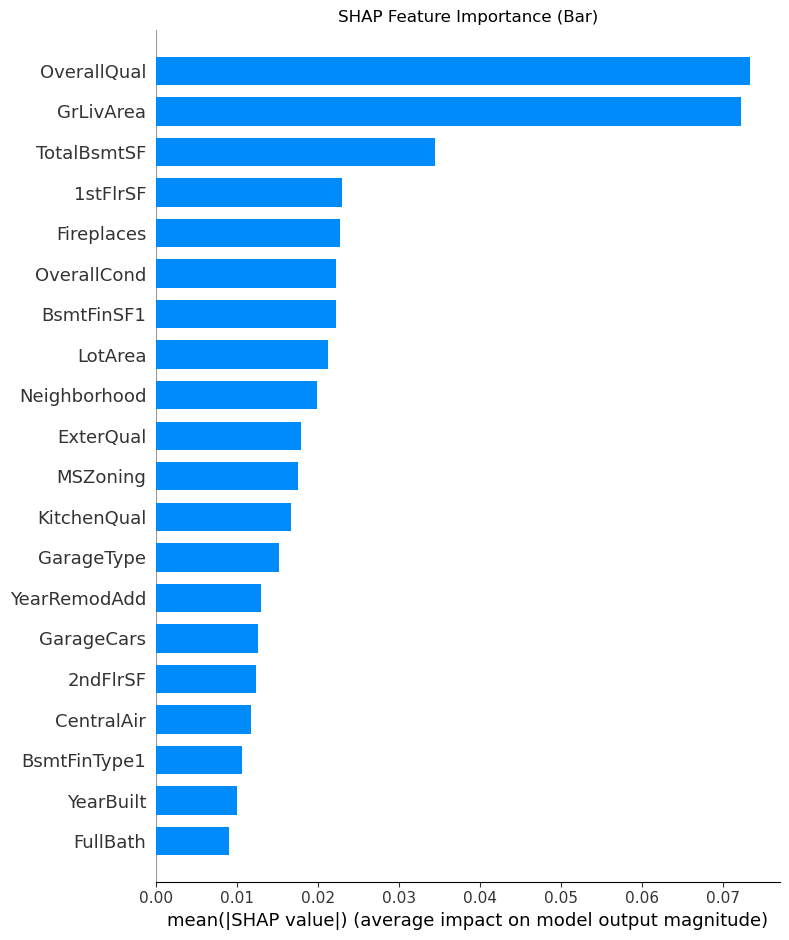

Global SHAP Importance:
         Feature  SHAP_Importance
16   OverallQual         0.073386
45     GrLivArea         0.072239
37   TotalBsmtSF         0.034460
42      1stFlrSF         0.022949
55    Fireplaces         0.022699
..           ...              ...
34  BsmtFinType2         0.000003
68     3SsnPorch         0.000000
4         Street         0.000000
8      Utilities         0.000000
47  BsmtHalfBath         0.000000

[79 rows x 2 columns]


In [117]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from catboost import Pool

# Assuming model, X_train, y_train_log, cat_features are defined
train_pool = Pool(X_train, y_log, cat_features=cat_features)

# Compute SHAP values
shap_importance = model.get_feature_importance(type="ShapValues", data=train_pool)

# Separate SHAP values and bias
shap_values = shap_importance[:, :-1]  # Exclude bias column
bias = shap_importance[:, -1]  # Bias column

# Normalize SHAP values (Min-Max to 0-1)
shap_min = np.min(shap_values)
shap_max = np.max(shap_values)
shap_range = shap_max - shap_min
if shap_range != 0:  # Avoid division by zero
    shap_values_normalized = (shap_values - shap_min) / shap_range
else:
    shap_values_normalized = shap_values  # No normalization if range is 0

# Create SHAP Explanation object (use normalized values for visualization)
explainer = shap.Explainer(model)
shap_explanation = shap.Explanation(values=shap_values_normalized, base_values=bias, data=X_train, feature_names=X_train.columns)

# 1. Summary Plot (Beeswarm): Shows normalized feature impact
shap.summary_plot(shap_values_normalized, X_train, max_display=30, show=False)
plt.title("SHAP Summary Plot (Normalized)")
plt.tight_layout()
plt.show()

# 2. Bar Plot: Global feature importance (use original SHAP values for accuracy)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.show()

# Print global importance (using original SHAP values)
global_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "SHAP_Importance": np.abs(shap_values).mean(axis=0)
}).sort_values(by="SHAP_Importance", ascending=False)
print("Global SHAP Importance:")
print(global_importance)

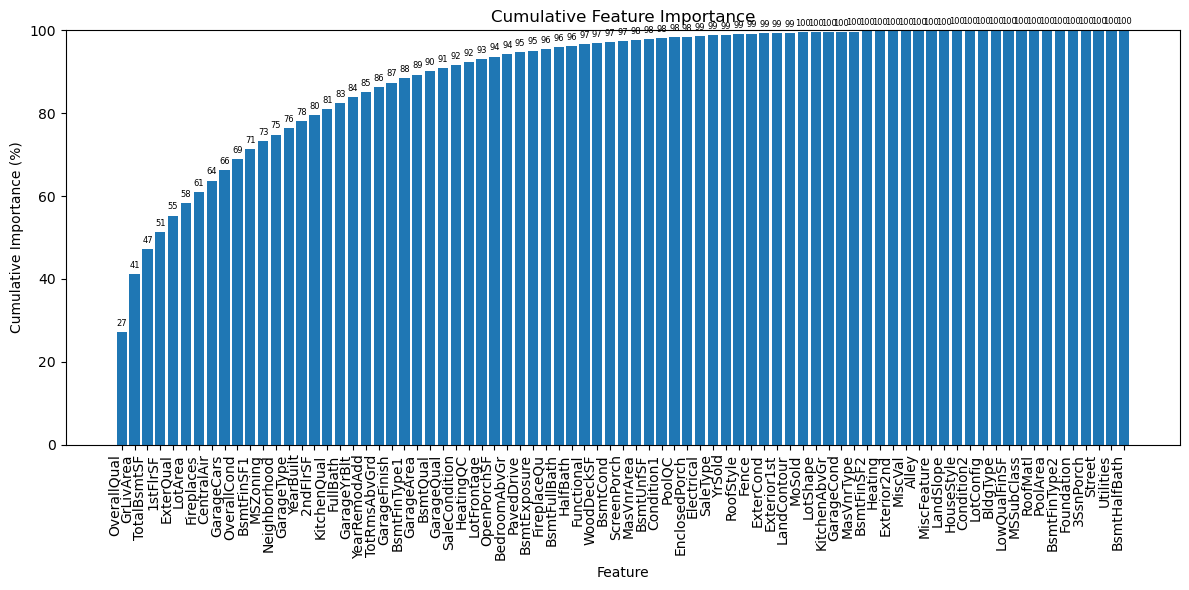

In [118]:
importance["Cumulative_Importance"] = importance["Importance"].cumsum()

# Create bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(importance["Feature"], importance["Cumulative_Importance"])
plt.xlabel("Feature")
plt.ylabel("Cumulative Importance (%)")
plt.title("Cumulative Feature Importance")
plt.xticks(rotation=90, ha="right")
plt.ylim(0, 100)  # Set y-axis to 0-100%

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.0f}", 
             ha="center", va="bottom", fontsize=6)

plt.tight_layout()
plt.show()

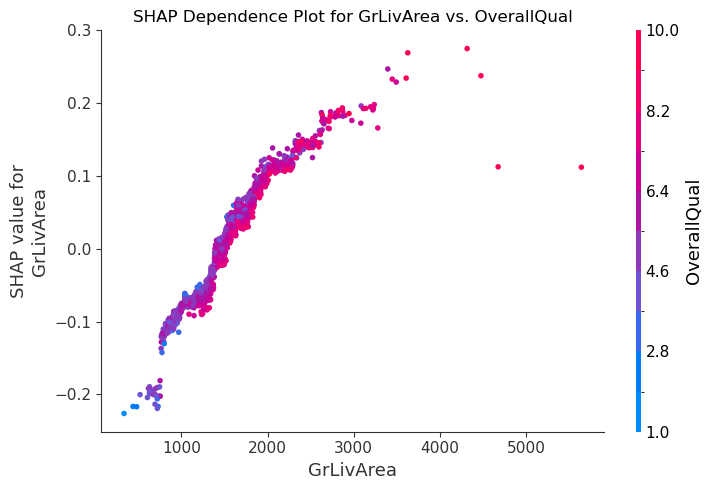

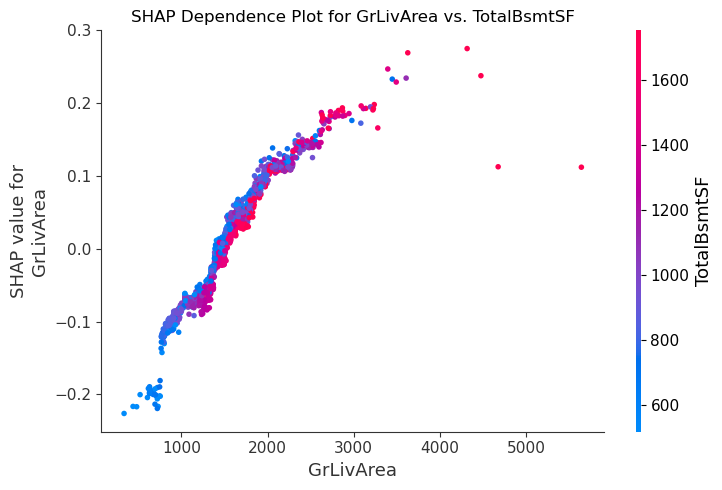

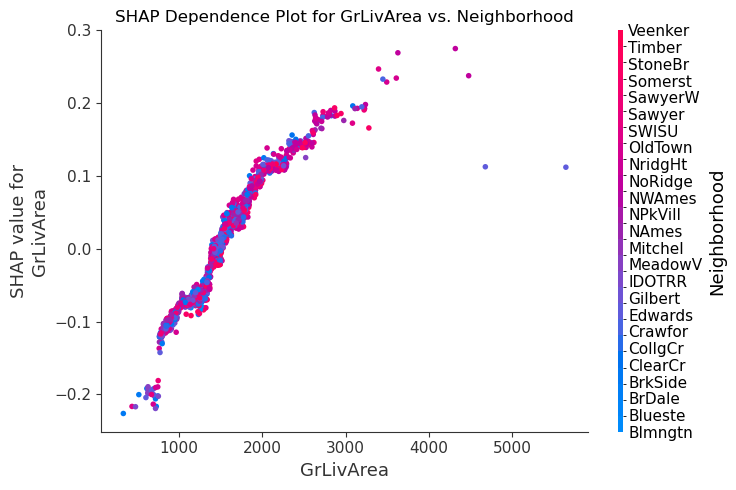

In [119]:
# List of features to explore interactions with GrLivArea
interaction_features = ["OverallQual", "TotalBsmtSF", "Neighborhood"]

# Generate dependence plots for each interaction
for feature in interaction_features:
    shap.dependence_plot("GrLivArea", shap_values, X_train, interaction_index=feature, show=False)
    plt.title(f"SHAP Dependence Plot for GrLivArea vs. {feature}")
    plt.tight_layout()
    plt.show()

In [120]:
global_importance["Cumulative_SHAP_Importance"] = global_importance["SHAP_Importance"].cumsum()

# Normalize cumulative importance to percentages (0-100)
importance["Cumulative_Importance"] = (importance["Cumulative_Importance"] / importance["Importance"].sum()) * 100
global_importance["Cumulative_SHAP_Importance"] = (global_importance["Cumulative_SHAP_Importance"] / global_importance["SHAP_Importance"].sum()) * 100

# Features up to 90% cumulative importance (Regular)
regular_90 = importance[importance["Cumulative_Importance"] <= 90]["Feature"].tolist()
print("Features up to 90% Regular Cumulative Importance:")
print(regular_90)
print(f"Number of features: {len(regular_90)}")

# Features up to 90% cumulative importance (SHAP)
shap_90 = global_importance[global_importance["Cumulative_SHAP_Importance"] <= 90]["Feature"].tolist()
print("\nFeatures up to 90% SHAP Cumulative Importance:")
print(shap_90)
print(f"Number of features: {len(shap_90)}")

# Compare: Common features, unique to each
common_features = set(regular_90) & set(shap_90)
regular_only = set(regular_90) - set(shap_90)
shap_only = set(shap_90) - set(regular_90)

print("\nComparison:")
print(f"Common Features ({len(common_features)}): {sorted(common_features)}")
print(f"Unique to Regular ({len(regular_only)}): {sorted(regular_only)}")
print(f"Unique to SHAP ({len(shap_only)}): {sorted(shap_only)}")

Features up to 90% Regular Cumulative Importance:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'ExterQual', 'LotArea', 'Fireplaces', 'CentralAir', 'GarageCars', 'OverallCond', 'BsmtFinSF1', 'MSZoning', 'Neighborhood', 'GarageType', 'YearBuilt', '2ndFlrSF', 'KitchenQual', 'FullBath', 'GarageYrBlt', 'YearRemodAdd', 'TotRmsAbvGrd', 'GarageFinish', 'BsmtFinType1', 'GarageArea']
Number of features: 24

Features up to 90% SHAP Cumulative Importance:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'Fireplaces', 'OverallCond', 'BsmtFinSF1', 'LotArea', 'Neighborhood', 'ExterQual', 'MSZoning', 'KitchenQual', 'GarageType', 'YearRemodAdd', 'GarageCars', '2ndFlrSF', 'CentralAir', 'BsmtFinType1', 'YearBuilt', 'FullBath', 'HeatingQC', 'SaleCondition', 'GarageFinish', 'TotRmsAbvGrd', 'OpenPorchSF', 'WoodDeckSF', 'GarageArea', 'BsmtFullBath', 'GarageQual', 'BsmtQual', 'FireplaceQu', 'Functional']
Number of features: 32

Comparison:
Common Features (23): ['1stFlrSF', '2ndFlrSF', 'Bsmt

In [121]:
# Identify common and unique features
common_features = set(regular_90) & set(shap_90)
regular_only = set(regular_90) - set(shap_90)
shap_only = set(shap_90) - set(regular_90)

# Extract importance scores for unique features (Regular)
regular_unique_df = importance[importance["Feature"].isin(regular_only)][["Feature", "Importance", "Cumulative_Importance"]]
print("Unique Regular Features Importance:")
print(regular_unique_df)

# Extract importance scores for unique features (SHAP)
shap_unique_df = global_importance[global_importance["Feature"].isin(shap_only)][["Feature", "SHAP_Importance", "Cumulative_SHAP_Importance"]]
print("\nUnique SHAP Features Importance:")
print(shap_unique_df)

# Summary statistics for common features (for context)
common_regular_df = importance[importance["Feature"].isin(common_features)][["Feature", "Importance", "Cumulative_Importance"]]
common_shap_df = global_importance[global_importance["Feature"].isin(common_features)][["Feature", "SHAP_Importance", "Cumulative_SHAP_Importance"]]
print("\nSummary Statistics for Common Features (Regular):")
print(common_regular_df.describe())
print("\nSummary Statistics for Common Features (SHAP):")
print(common_shap_df.describe())

Unique Regular Features Importance:
        Feature  Importance  Cumulative_Importance
58  GarageYrBlt    1.371753              83.887386

Unique SHAP Features Importance:
          Feature  SHAP_Importance  Cumulative_SHAP_Importance
39      HeatingQC         0.008644                   77.777080
78  SaleCondition         0.008572                   79.205957
66    OpenPorchSF         0.006712                   82.871474
65     WoodDeckSF         0.006074                   83.884019
46   BsmtFullBath         0.005771                   85.844279
62     GarageQual         0.005681                   86.791346
29       BsmtQual         0.005586                   87.722530
56    FireplaceQu         0.005576                   88.652013
54     Functional         0.005200                   89.518759

Summary Statistics for Common Features (Regular):
       Importance  Cumulative_Importance
count   23.000000              23.000000
mean     3.823222              69.294328
std      5.773085       

In [122]:
common_features = list(common_features)

# Filter X_train and X_test to common features
X_train = X_train[common_features]
X_test = X_test[common_features]

# Update cat_features to only include categorical features in common_features
cat_features = [f for f in cat_features if f in common_features]

# Verify the shapes
print("X_train shape after filtering:", X_train.shape)
print("X_test shape after filtering:", X_test.shape)
print("Updated cat_features:", cat_features)

X_train shape after filtering: (1460, 23)
X_test shape after filtering: (1459, 23)
Updated cat_features: ['MSZoning', 'Neighborhood', 'ExterQual', 'BsmtFinType1', 'CentralAir', 'KitchenQual', 'GarageType', 'GarageFinish']


In [123]:
# Identify numerical features
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_features

['LotArea',
 'GarageCars',
 'YearBuilt',
 'Fireplaces',
 '1stFlrSF',
 'OverallCond',
 'FullBath',
 'OverallQual',
 'GrLivArea',
 'TotRmsAbvGrd',
 'GarageArea',
 'YearRemodAdd',
 '2ndFlrSF',
 'TotalBsmtSF',
 'BsmtFinSF1']

In [94]:
filtered_num_features = [col for col in num_features if col not in exclude_cols]
print("\nOutliers Detected (IQR Method):")
for col in filtered_num_features + ["SalePrice_log"]:
    if col == "SalePrice_log":
        n_outliers, lower, upper = detect_outliers(pd.DataFrame({"SalePrice_log": y_log}), "SalePrice_log")
    else:
        n_outliers, lower, upper = detect_outliers(X_train, col)
    print(f"{col}: {n_outliers} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")


Outliers Detected (IQR Method):
LotArea: 69 outliers (Lower: 1481.50, Upper: 17673.50)
1stFlrSF: 20 outliers (Lower: 118.12, Upper: 2155.12)
GrLivArea: 31 outliers (Lower: 158.62, Upper: 2747.62)
GarageArea: 21 outliers (Lower: -27.75, Upper: 938.25)
2ndFlrSF: 2 outliers (Lower: -1092.00, Upper: 1820.00)
TotalBsmtSF: 61 outliers (Lower: 42.00, Upper: 2052.00)
BsmtFinSF1: 7 outliers (Lower: -1068.38, Upper: 1780.62)
SalePrice_log: 28 outliers (Lower: 11.03, Upper: 13.02)


## Rerun Model to Assess Improvement

In [136]:
cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()
for col in cat_features:
    X_train[col] = X_train[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")

kf = KFold(n_splits=5, shuffle=True, random_state=42)


log_dir = "logs/catboost_cv_post_feature_selection_v6"


# Initialize TensorBoard writer
writer = SummaryWriter(log_dir=log_dir)

# Perform CV
fold = 0
rmses = []

for train_idx, val_idx in kf.split(X_train):
    fold += 1
    X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_t_log, y_v_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
    
    train_pool = Pool(X_t, y_t_log, cat_features=cat_features)
    val_pool = Pool(X_v, y_v_log, cat_features=cat_features)
    
    model = CatBoostRegressor(
        early_stopping_rounds=20,
        depth=4,
        learning_rate=0.05,
        l2_leaf_reg=1,
        loss_function="RMSE",
        verbose=1
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    
    # Log metrics for this fold
    for i, (train_rmse, val_rmse) in enumerate(zip(model.evals_result_["learn"]["RMSE"], model.evals_result_["validation"]["RMSE"])):
        writer.add_scalar(f"Fold_{fold}/Train_RMSE", train_rmse, i)
        writer.add_scalar(f"Fold_{fold}/Val_RMSE", val_rmse, i)
        
        # Compute validation RMSE
    y_pred_log = model.predict(X_v)
    rmse = np.sqrt(mean_squared_error(y_v_log, y_pred_log))
    rmses.append(rmse)
    print(f"Fold {fold} RMSE: {rmse:.4f}")

writer.close()
print(f"Average CV RMSE: {np.mean(rmses):.4f}")

writer.close()

/var/folders/kf/sp0jlhvs3yb2h_z31jyqkzrc0000gn/T/ipykernel_1517/1293198933.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



0:	learn: 0.3780006	test: 0.4204048	best: 0.4204048 (0)	total: 2.04ms	remaining: 2.04s
1:	learn: 0.3671249	test: 0.4092289	best: 0.4092289 (1)	total: 5.3ms	remaining: 2.65s
2:	learn: 0.3555915	test: 0.3971489	best: 0.3971489 (2)	total: 6.35ms	remaining: 2.11s
3:	learn: 0.3454241	test: 0.3862370	best: 0.3862370 (3)	total: 7.48ms	remaining: 1.86s
4:	learn: 0.3356806	test: 0.3756253	best: 0.3756253 (4)	total: 8.64ms	remaining: 1.72s
5:	learn: 0.3272629	test: 0.3667096	best: 0.3667096 (5)	total: 9.82ms	remaining: 1.63s
6:	learn: 0.3180985	test: 0.3567722	best: 0.3567722 (6)	total: 11.4ms	remaining: 1.61s
7:	learn: 0.3098307	test: 0.3481649	best: 0.3481649 (7)	total: 12.8ms	remaining: 1.59s
8:	learn: 0.3014860	test: 0.3393777	best: 0.3393777 (8)	total: 14ms	remaining: 1.54s
9:	learn: 0.2930992	test: 0.3301125	best: 0.3301125 (9)	total: 15.3ms	remaining: 1.52s
10:	learn: 0.2856250	test: 0.3218176	best: 0.3218176 (10)	total: 16.3ms	remaining: 1.47s
11:	learn: 0.2786161	test: 0.3147902	best: 0

/var/folders/kf/sp0jlhvs3yb2h_z31jyqkzrc0000gn/T/ipykernel_1517/3656191194.py:5: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



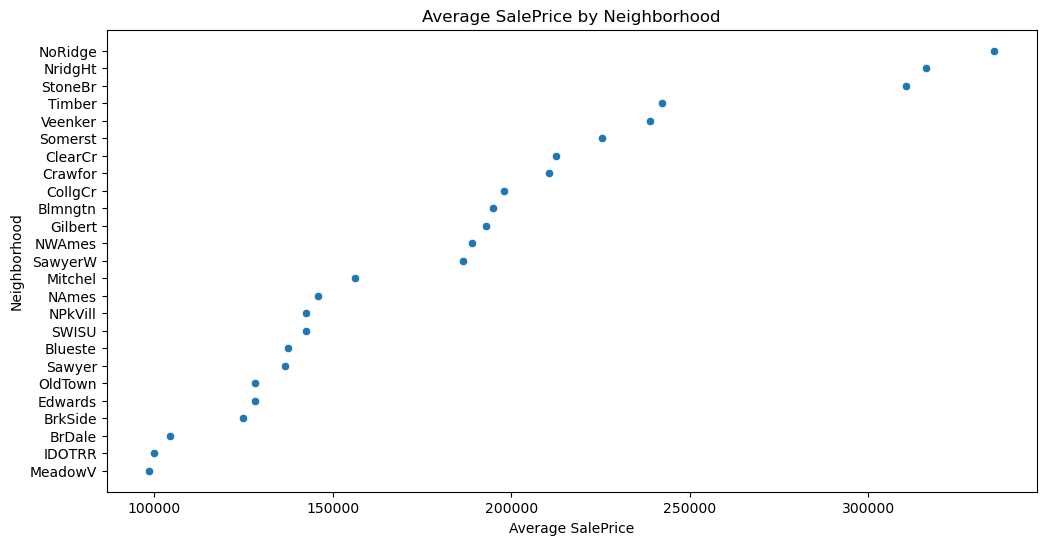

In [99]:
# make scatter plot showing aggregate sales price by neighborhood
agg_sales = train.groupby("Neighborhood")["SalePrice"].mean().reset_index()
agg_sales = agg_sales.sort_values(by="SalePrice", ascending=False)
plt.figure(figsize=(12, 6))
sns.scatterplot(x="SalePrice", y="Neighborhood", data=agg_sales, palette="viridis")
plt.title("Average SalePrice by Neighborhood")
plt.xlabel("Average SalePrice")
plt.ylabel("Neighborhood")
plt.show()

In [137]:
log_dir = "logs/catboost_predict_v2"


# Initialize TensorBoard writer
writer = SummaryWriter(log_dir=log_dir)

# Train final model on full data
final_model = CatBoostRegressor(
    early_stopping_rounds=20,
    depth=4,
    learning_rate=0.05,
    l2_leaf_reg=1,
    loss_function="RMSE",
    verbose=100,
)
train_pool = Pool(X_train, y_log, cat_features=cat_features)
final_model.fit(train_pool)

writer.close()

# Predict on test set
test_pool = Pool(X_test, cat_features=cat_features)
y_pred_log = final_model.predict(test_pool)
y_pred = np.expm1(y_pred_log)  # Back-transform to original scale

# Create submission
submission = pd.DataFrame({"Id": test_ids, "SalePrice": y_pred})
submission.to_csv("submission.csv", index=False)
print("Submission file created: submission.csv")

0:	learn: 0.3874495	total: 2.18ms	remaining: 2.18s
100:	learn: 0.1238991	total: 113ms	remaining: 1.01s
200:	learn: 0.1058749	total: 214ms	remaining: 852ms
300:	learn: 0.0961393	total: 303ms	remaining: 704ms
400:	learn: 0.0898246	total: 391ms	remaining: 584ms
500:	learn: 0.0853480	total: 490ms	remaining: 488ms
600:	learn: 0.0815233	total: 586ms	remaining: 389ms
700:	learn: 0.0779402	total: 679ms	remaining: 290ms
800:	learn: 0.0745073	total: 779ms	remaining: 194ms
900:	learn: 0.0713434	total: 888ms	remaining: 97.6ms
999:	learn: 0.0680550	total: 1s	remaining: 0us
Submission file created: submission.csv
